pip install nibabel

pip install nilearn

In [144]:
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from nilearn import plotting
from nilearn.image import coord_transform

En primer lugar. vamos a revisar el archivo de descripción de los datos.

In [120]:
archivo = pd.read_csv("T1_age_gender_evaluation.csv")
print(len(archivo))
print(archivo.duplicated().sum())
print(archivo.columns)
print("--------------------------------------")
print(open("labels.txt").read())

310
0
Index(['Patient ID', 'Age', 'Gender', 'Radiological Evaluation'], dtype='str')
--------------------------------------
Gender:
1 = Female
2 = Male

Radiological Evaluation:
1 = Mild
2 = Moderate
3 = Severe



Vamos a mostrar algunos ejemplos de los datos

In [121]:
archivo.head()

,Patient ID,Age,Gender,Radiological Evaluation
0,4,60,2,3
1,5,61,1,1
2,8,63,2,3
3,9,49,2,3
4,10,51,2,3


Ahora vamos a revisar si los tamaños de las imagenes T1 y T2 coinciden

In [154]:

train_images = os.listdir("train_images")
train_images_2 = os.listdir("train_images_2")
valid_images = os.listdir("valid_images")
valid_images_2 = os.listdir("valid_images_2")
test_images = os.listdir("test_images")
test_images_2 = os.listdir("test_images_2")

print("Train images T1:", len(train_images))
print("Train images T2:", len(train_images_2))
print("Validation images T1:", len(valid_images))
print("Validation images T2:", len(valid_images_2))
print("Test images T1:", len(test_images))
print("Test images T2:", len(test_images_2))
print("Total images:", len(train_images) + len(train_images_2) + len(valid_images) + len(valid_images_2) + len(test_images) + len(test_images_2))

Train images T1: 248
Train images T2: 256
Validation images T1: 31
Validation images T2: 31
Test images T1: 31
Test images T2: 31
Total images: 628


Notamos que hay más imagenes de T2 que T1 por tanto es probable que tengamos que eliminar los registros que no tengan su pareja en T1

Ahora vamos a revisar las dimensiones de las imagenes.

In [155]:
shapes = []

for file in train_images:
    path = os.path.join("train_images", file)
    img = nib.load(path)
    shapes.append(img.shape)

print("Dimensiones únicas T1:", set(shapes))
print("Número de dimensiones únicas T1:", len(set(shapes)))

shapes_2 = []
for file in train_images_2:
    path = os.path.join("train_images_2", file)
    img = nib.load(path)
    shapes_2.append(img.shape)
print("Dimensiones únicas T2:", set(shapes_2))
print("Número de dimensiones únicas T2:", len(set(shapes_2)))

Dimensiones únicas T1: {(432, 432, 160), (320, 230, 80), (256, 192, 30), (320, 260, 72), (448, 448, 192), (400, 400, 160), (384, 384, 115), (448, 448, 140), (352, 352, 114), (256, 176, 64), (256, 192, 60), (384, 384, 185), (352, 352, 123), (320, 260, 96), (432, 432, 25), (336, 336, 115), (352, 352, 135), (320, 280, 80), (432, 432, 150), (256, 160, 64), (260, 320, 80), (320, 240, 80), (320, 258, 104), (384, 384, 160), (400, 400, 150), (256, 208, 80), (256, 176, 60), (320, 260, 80), (480, 480, 31), (480, 480, 150), (432, 432, 180), (384, 384, 120), (352, 352, 122), (432, 432, 192), (400, 400, 180), (256, 176, 72), (192, 192, 120), (400, 400, 125), (320, 320, 115), (320, 260, 104), (352, 352, 140), (256, 208, 64), (384, 384, 150), (320, 260, 64), (400, 400, 100), (256, 176, 56), (352, 352, 115), (320, 260, 88), (320, 270, 80), (384, 384, 119), (352, 352, 121), (352, 352, 130), (256, 192, 64), (320, 240, 72)}
Número de dimensiones únicas T1: 54
Dimensiones únicas T2: {(432, 432, 32), (640,

Notamos que las imagenes no vienen en las misma dimenciones. Esto es un problema que tendremos que solucionar.

Vamos a revisar las slides de profundidad de cada imagen

In [156]:
slice_counts = []

for file in train_images[:20]:  # analizar algunos
    img = nib.load("train_images/" + file)
    slice_counts.append(img.get_fdata().shape[2])

print("Min slices:", np.min(slice_counts))
print("Max slices:", np.max(slice_counts))
print("Average slices:", np.mean(slice_counts))

Min slices: 31
Max slices: 115
Average slices: 79.6


Notamos que hay imagenes con demasiado pocas slices, es algo que tendremos que revisar a fondo.

Ahora vamos a revisar la integridad de los datos en las carpetas. Vamos a ver si se emparejan con sus mascaras y si el grosor de la imagen es coherente

In [157]:
# 1. Configuración de rutas
path_imgs = 'train_images'
path_masks = 'train_masks'
datos_espaciales = []
path_imgs2 = 'train_images_2'
path_masks2 = 'train_masks_2'
datos_espaciales2 = []

# Listar archivos en ambas carpetas
archivos_imgs = set([f for f in os.listdir(path_imgs) if f.endswith('.nii')])
archivos_masks = set([f for f in os.listdir(path_masks) if f.endswith('.nii')])
archivos_imgs2 = set([f for f in os.listdir(path_imgs2) if f.endswith('.nii')])
archivos_masks2 = set([f for f in os.listdir(path_masks2) if f.endswith('.nii')])


# 2. Análisis de emparejamiento
emparejados = archivos_imgs.intersection(archivos_masks)
solo_imgs = archivos_imgs - archivos_masks
solo_masks = archivos_masks - archivos_imgs

print("=" * 60)
print("REPORTE DE INTEGRIDAD DEL DATASET")
print("=" * 60)
print(f"Total de imágenes encontradas: {len(archivos_imgs)}")
print(f"Total de máscaras encontradas: {len(archivos_masks)}")
print(f"Parejas exitosas:             {len(emparejados)}")
print(f"Imágenes SIN máscara:          {len(solo_imgs)}")
print(f"Máscaras SIN imagen:           {len(solo_masks)}")
if solo_imgs:
    print(f"\nArchivos de imagen huérfanos (sin máscara): {list(solo_imgs)}")
if solo_masks:
    print(f"\nArchivos de máscara huérfanos (sin imagen): {list(solo_masks)}")
print("=" * 60 + "\n")


emparejados2 = archivos_imgs2.intersection(archivos_masks2)
solo_imgs2 = archivos_imgs2 - archivos_masks2
solo_masks2 = archivos_masks2 - archivos_imgs2
print("\n" + "=" * 60)
print("REPORTE DE INTEGRIDAD DEL DATASET (T2)")
print("=" * 60)
print(f"Total de imágenes encontradas: {len(archivos_imgs2)}")
print(f"Total de máscaras encontradas: {len(archivos_masks2)}")
print(f"Parejas exitosas:             {len(emparejados2)}")
print(f"Imágenes SIN máscara:          {len(solo_imgs2)}")
print(f"Máscaras SIN imagen:           {len(solo_masks2)}")

if solo_imgs2:
    print(f"\nArchivos de imagen huérfanos (sin máscara): {list(solo_imgs2)}")
if solo_masks2:
    print(f"\nArchivos de máscara huérfanos (sin imagen): {list(solo_masks2)}")
print("=" * 60 + "\n")


# 3. Procesamiento de los emparejados para hallar rangos
for nombre_archivo in emparejados:
    try:
        img_path = os.path.join(path_imgs, nombre_archivo)
        img_obj = nib.load(img_path)
        affine = img_obj.affine
        
        z_min_idx = 0
        z_max_idx = img_obj.shape[2] - 1
        
        x_inicio, y_inicio, z_inicio = coord_transform(0, 0, z_min_idx, affine)
        x_fin, y_fin, z_fin = coord_transform(0, 0, z_max_idx, affine)
        
        rango_total = abs(z_fin - z_inicio)
        
        datos_espaciales.append({
            'Archivo': nombre_archivo,
            'Z_Inicio_mm': z_inicio,
            'Z_Fin_mm': z_fin,
            'Rango_Total_mm': rango_total,
            'Cortes': img_obj.shape[2]
        })
    except Exception as e:
        print(f"Error procesando {nombre_archivo}: {e}")
for nombre_archivo in emparejados2:
        try:
            img_path = os.path.join(path_imgs2, nombre_archivo)
            img_obj = nib.load(img_path)
            affine = img_obj.affine
            
            z_min_idx = 0
            z_max_idx = img_obj.shape[2] - 1
            
            x_inicio, y_inicio, z_inicio = coord_transform(0, 0, z_min_idx, affine)
            x_fin, y_fin, z_fin = coord_transform(0, 0, z_max_idx, affine)
            
            rango_total = abs(z_fin - z_inicio)
            
            datos_espaciales2.append({
                'Archivo': nombre_archivo,
                'Z_Inicio_mm': z_inicio,
                'Z_Fin_mm': z_fin,
                'Rango_Total_mm': rango_total,
                'Cortes': img_obj.shape[2]
            })
        except Exception as e:
            print(f"Error procesando {nombre_archivo}: {e}")

# 4. Resultados Estadísticos Finales
if datos_espaciales:
    df = pd.DataFrame(datos_espaciales)
    print("\n" + "=" * 50)
    print("ESTADÍSTICAS ESPACIALES (Solo emparejados)")
    print("=" * 50)
    print(f"Rango Promedio: {df['Rango_Total_mm'].mean():.2f} mm")
    print(f"Rango Mínimo:   {df['Rango_Total_mm'].min():.2f} mm")
    print(f"Rango Máximo:   {df['Rango_Total_mm'].max():.2f} mm")
    
    # Alerta por el error que encontramos antes
    errores = df[df['Rango_Total_mm'] <= 1.0]
    if not errores.empty:
        print("-" * 50)
        print(f"¡ALERTA! Se detectaron {len(errores)} archivos con rango 0.")
        print(f"Archivos afectados: {errores['Archivo'].tolist()}")
    print("=" * 50)
if datos_espaciales2:
    df2 = pd.DataFrame(datos_espaciales2)
    print("\n" + "=" * 50)
    print("ESTADÍSTICAS ESPACIALES (Solo emparejados T2)")
    print("=" * 50)
    print(f"Rango Promedio: {df2['Rango_Total_mm'].mean():.2f} mm")
    print(f"Rango Mínimo:   {df2['Rango_Total_mm'].min():.2f} mm")
    print(f"Rango Máximo:   {df2['Rango_Total_mm'].max():.2f} mm")
    
    errores2 = df2[df2['Rango_Total_mm'] <= 1.0]
    if not errores2.empty:
        print("-" * 50)
        print(f"¡ALERTA! Se detectaron {len(errores2)} archivos con rango 0 en T2.")
        print(f"Archivos afectados: {errores2['Archivo'].tolist()}")
    print("=" * 50)

REPORTE DE INTEGRIDAD DEL DATASET
Total de imágenes encontradas: 248
Total de máscaras encontradas: 248
Parejas exitosas:             248
Imágenes SIN máscara:          0
Máscaras SIN imagen:           0


REPORTE DE INTEGRIDAD DEL DATASET (T2)
Total de imágenes encontradas: 256
Total de máscaras encontradas: 256
Parejas exitosas:             256
Imágenes SIN máscara:          0
Máscaras SIN imagen:           0


ESTADÍSTICAS ESPACIALES (Solo emparejados)
Rango Promedio: 265.31 mm
Rango Mínimo:   0.00 mm
Rango Máximo:   370.52 mm
--------------------------------------------------
¡ALERTA! Se detectaron 1 archivos con rango 0.
Archivos afectados: ['443.nii']

ESTADÍSTICAS ESPACIALES (Solo emparejados T2)
Rango Promedio: 255.44 mm
Rango Mínimo:   208.80 mm
Rango Máximo:   356.37 mm


Encontramos un dato sospechoso. sale como si hubieeran tomado 140 fotos de la misma zona

Ahora vammos a investigar más a fondo con un ejemplo puntutal. El paciente de id 4. Todo esto para darnos una idea de como se ven las MRI

In [125]:
# cargar imagen MRI
img = nib.load("4f.nii")
data = img.get_fdata()
img2 = nib.load("4f2.nii")
data2 = img2.get_fdata()

# cargar máscara
mask_img = nib.load("4.nii")
mask = mask_img.get_fdata()
mask_img2 = nib.load("42.nii")
mask2 = mask_img2.get_fdata()

mask_pixels = np.sum(mask)
total_pixels = mask.size

print("Min:", mask.min())
print("Max:", mask.max())
print("Porcentaje que abarca:", mask_pixels / total_pixels)



Min: 0.0
Max: 1.0
Porcentaje que abarca: 0.08397130408653847


Note que solo el 8,3% de las imagenes son el higado

In [126]:
print ("Dimensiones de la imagen:", data.shape)

Dimensiones de la imagen: (320, 260, 80)


Vamos a mostrar varias slides de la imagen para entender su funcionamiento.

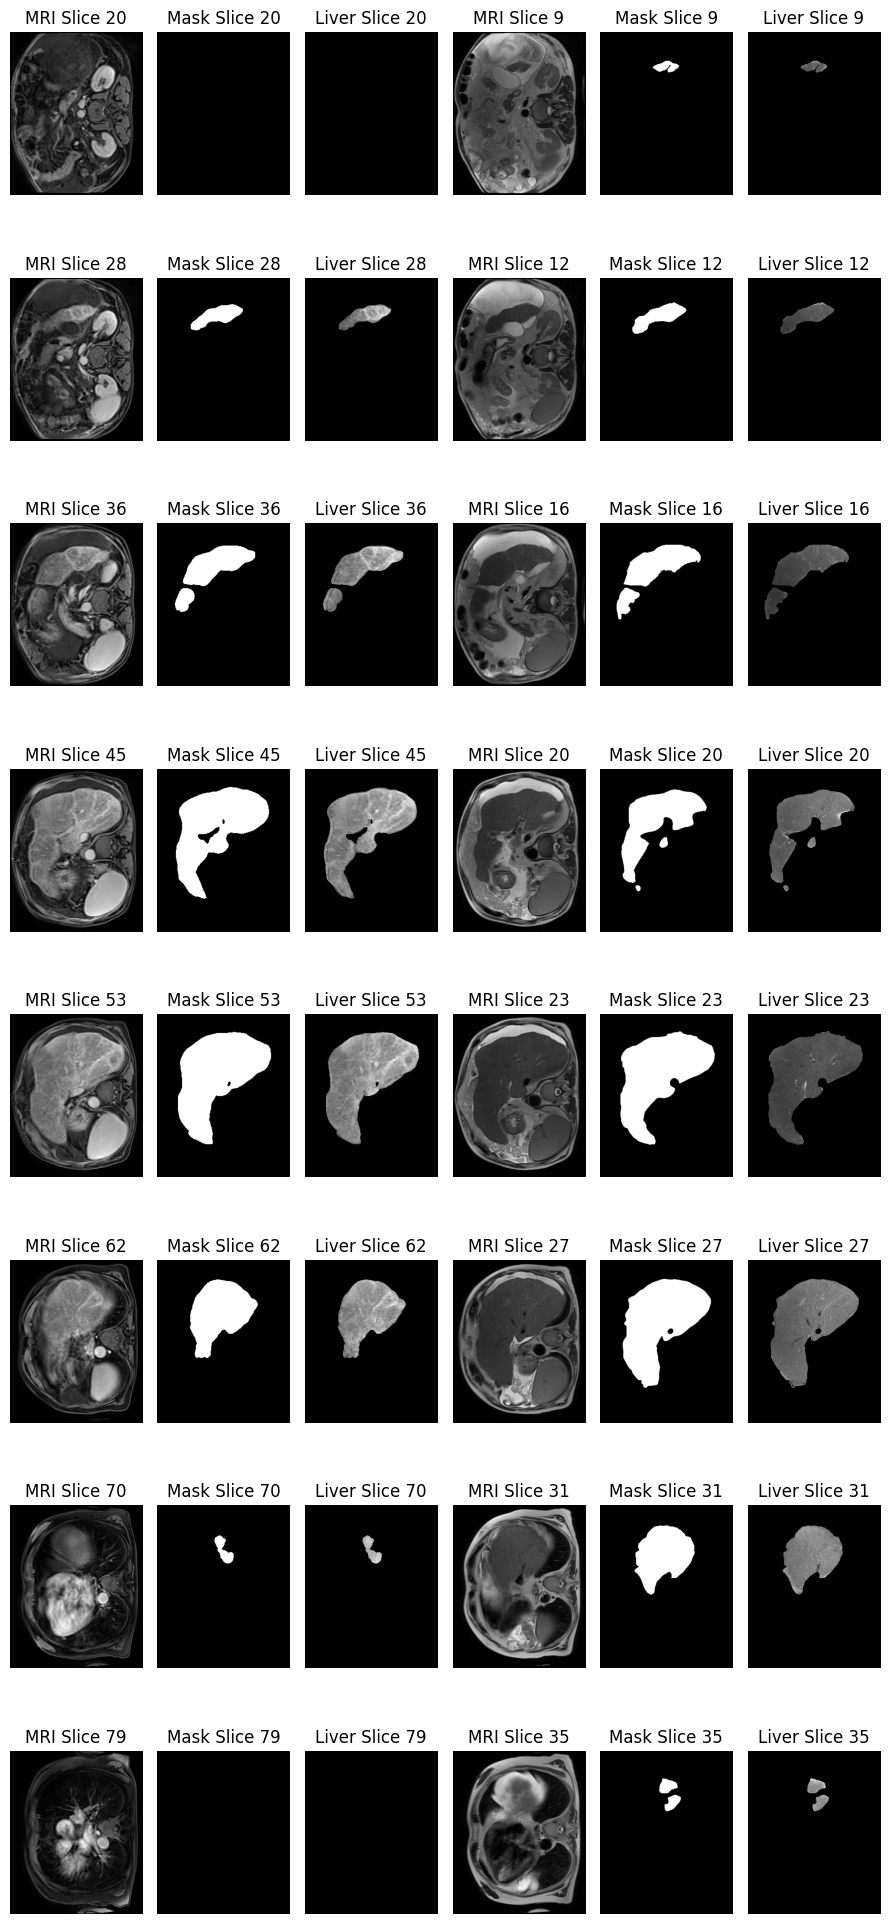

In [127]:
# rango de slices donde está el hígado
start = data.shape[2] // 4
end = data.shape[2] -1
start2 = data2.shape[2] // 4
end2 = data2.shape[2] -1

slices = np.linspace(start, end, 8).astype(int)
slices2 = np.linspace(start2, end2, 8).astype(int)

# ahora 3 columnas
fig, axes = plt.subplots(8, 6, figsize=(9, 20))

for i, s in enumerate(slices):
    
    # MRI original
    axes[i,0].imshow(data[:,:,s], cmap="gray")
    axes[i,0].set_title(f"MRI Slice {s}")
    axes[i,0].axis("off")
    
    # máscara
    axes[i,1].imshow(mask[:,:,s], cmap="gray")
    axes[i,1].set_title(f"Mask Slice {s}")
    axes[i,1].axis("off")
    
    # aplicar máscara (solo hígado)
    liver_only = data[:,:,s] * mask[:,:,s]

    axes[i,2].imshow(liver_only, cmap="gray")
    axes[i,2].set_title(f"Liver Slice {s}")
    axes[i,2].axis("off")
    
for i, s in enumerate(slices2):
    # MRI original T2
    axes[i,3].imshow(data2[:,:,s], cmap="gray")
    axes[i,3].set_title(f"MRI Slice {s}")
    axes[i,3].axis("off")
    
    # máscara T2
    axes[i,4].imshow(mask2[:,:,s], cmap="gray")
    axes[i,4].set_title(f"Mask Slice {s}")
    axes[i,4].axis("off")
    
    # aplicar máscara T2(solo hígado)
    liver_only = data2[:,:,s] * mask2[:,:,s]

    axes[i,5].imshow(liver_only, cmap="gray")
    axes[i,5].set_title(f"Liver Slice {s}")
    axes[i,5].axis("off")

plt.tight_layout()
plt.show()

Notamos varios asuntos. 
En primer lugar las dimenciones de T1 y T2 no coinciden. Esto puede ser problematico.
En segundo lugar vemos que las imagenes de interes se encuentras en las slides 45 y 62 para T1 y 20 y 27 para T2.

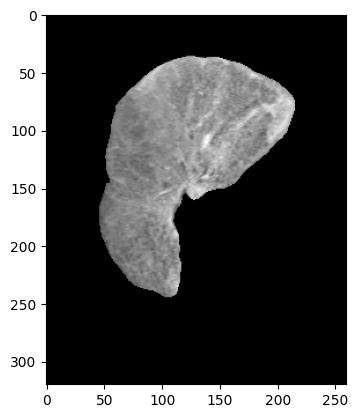

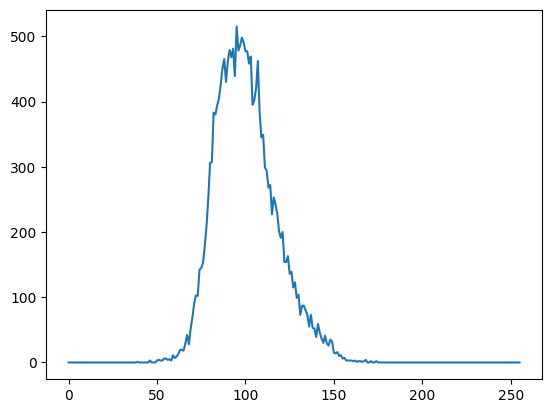

In [128]:

img57 = data[:,:,57] * mask[:,:,57]
plt.imshow(img57, cmap="gray")
plt.show()

vals = img57[(img57 >= 1)]
hist = cv2.calcHist([vals.astype(np.uint8)], [0], None, [256], [0,256])
plt.plot(hist)
plt.show()

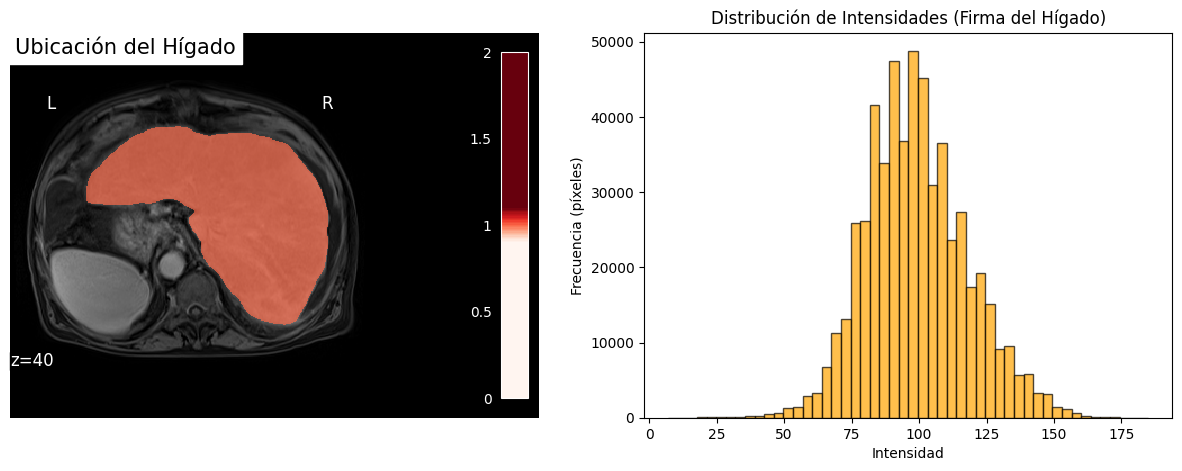

In [129]:

#Extraemos donde está el hígado usando la máscara
liver_values = data[mask > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
#aquí graficamos la ubicación del hígado usando nilearn
plotting.plot_roi(mask_img, bg_img=img, display_mode='z', cmap="Reds", 
                  cut_coords=[img.shape[2]//2], axes=ax1, title="Ubicación del Hígado")

#ahora el histograma de intensidades del hígado
ax2.hist(liver_values, bins=50, color='orange', edgecolor='black', alpha=0.7)
ax2.set_title("Distribución de Intensidades (Firma del Hígado)")
ax2.set_xlabel("Intensidad")
ax2.set_ylabel("Frecuencia (píxeles)")
plt.show()


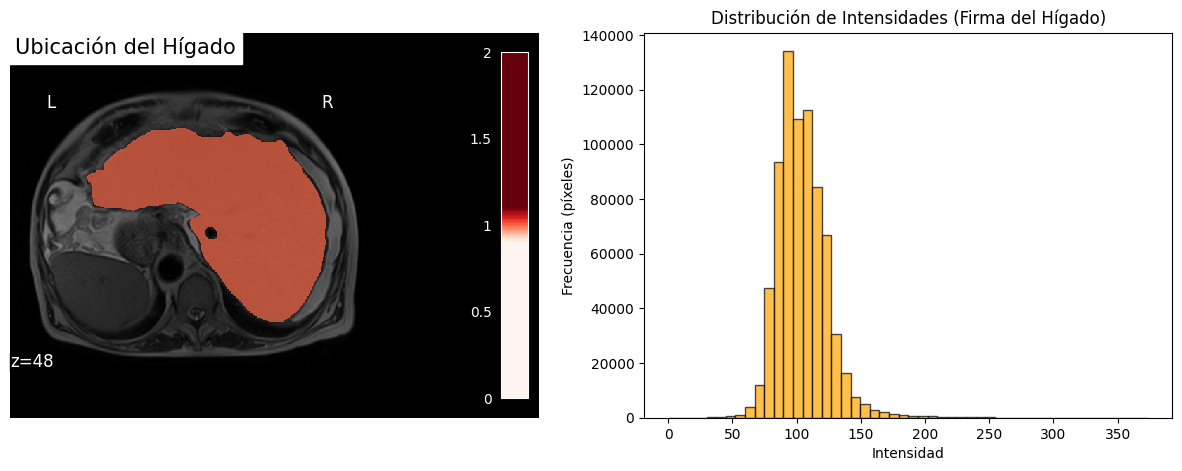

In [130]:

#Extraemos donde está el hígado usando la máscara
liver_values = data2[mask2 > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
#aquí graficamos la ubicación del hígado usando nilearn
plotting.plot_roi(mask_img2, bg_img=img2, display_mode='z', cmap="Reds", 
                  cut_coords=[(img2.shape[2]//2)+30], axes=ax1, title="Ubicación del Hígado")

#ahora el histograma de intensidades del hígado
ax2.hist(liver_values, bins=50, color='orange', edgecolor='black', alpha=0.7)
ax2.set_title("Distribución de Intensidades (Firma del Hígado)")
ax2.set_xlabel("Intensidad")
ax2.set_ylabel("Frecuencia (píxeles)")
plt.show()

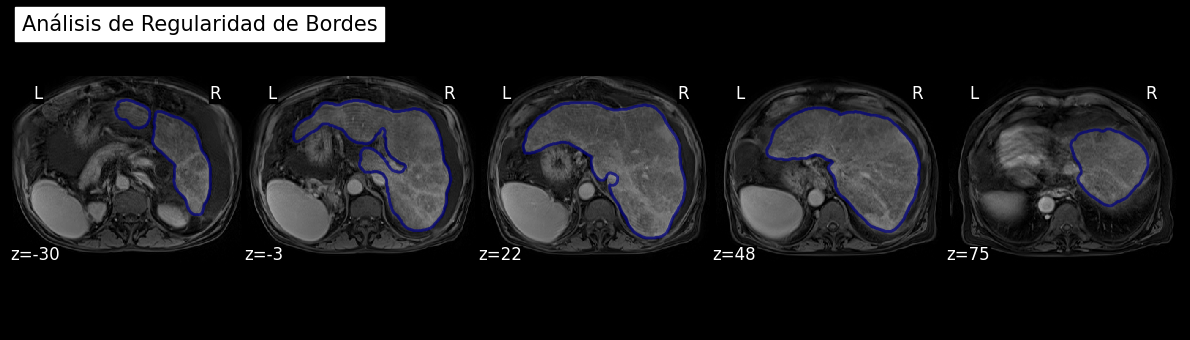

In [131]:

plotting.plot_roi(mask_img, bg_img=img, 
                  display_mode='z', cut_coords=5, 
                  view_type='contours', 
                  title="Análisis de Regularidad de Bordes",
                  linewidths=2)
plotting.show()


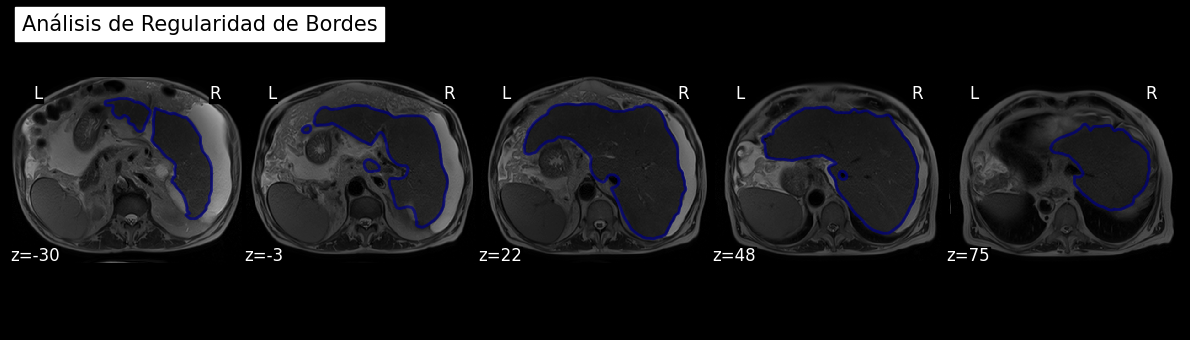

In [134]:
plotting.plot_roi(mask_img2, bg_img=img2, 
                  display_mode='z', cut_coords=5, 
                  view_type='contours', 
                  title="Análisis de Regularidad de Bordes",
                  linewidths=2)
plotting.show()
